In [35]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.stats import sigma_clipped_stats
from astropy.visualization import AsinhStretch, ImageNormalize

image = '../src/cutouts_physical/phys_src_00059.fits'
file = fits.open(image)
sci = file["SCI"].data.astype(float)
err = file["ERR"].data.astype(float)

mean, sky_median, sky_std = sigma_clipped_stats(sci, sigma=3.0)
print(f"sky median = {sky_median:.4f}   sky std = {sky_std:.4f}   peak = {np.nanmax(sci):.4f}")

sky median = 0.0283   sky std = 0.0491   peak = 4.2656


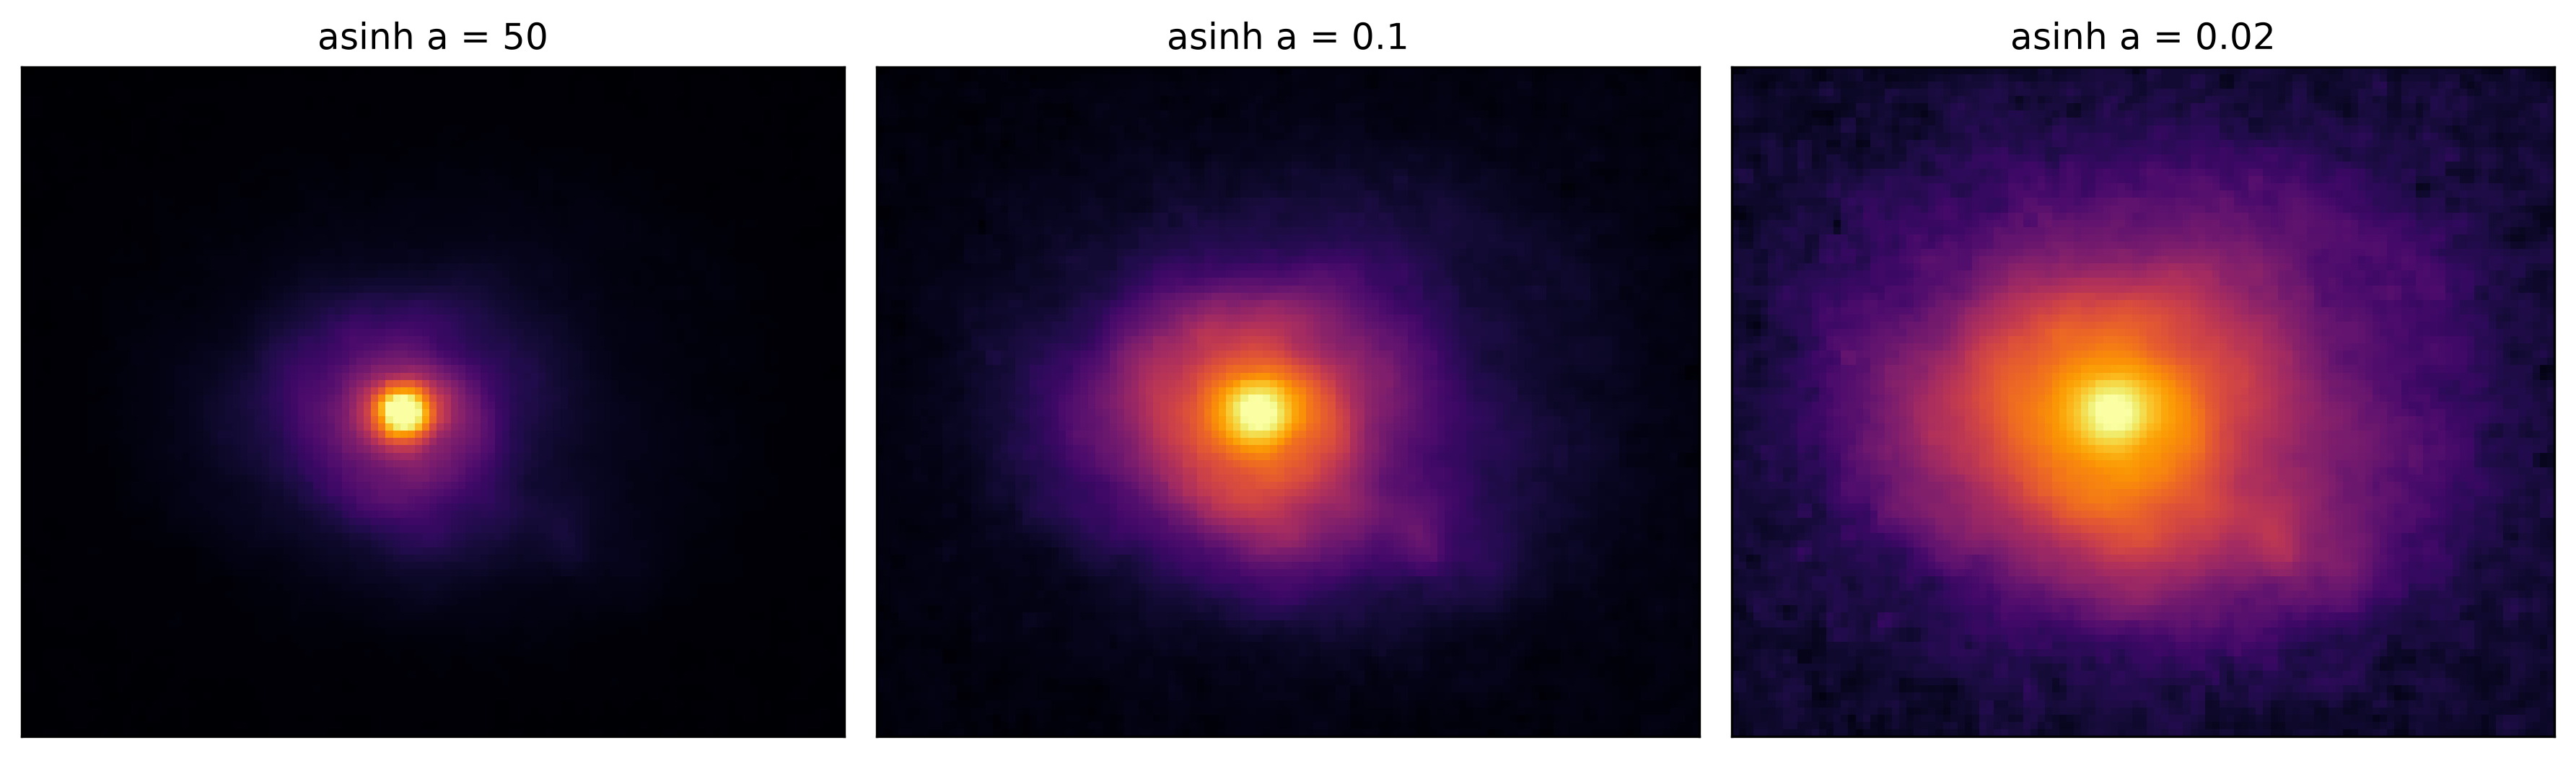

In [36]:
vmin = sky_median - 1.0 * sky_std
vmax = np.nanpercentile(sci, 99.9)

a_values = [50, 0.1, 0.02]
fig, axes = plt.subplots(1, len(a_values), figsize=(4*len(a_values), 4), dpi=300)
for ax, a in zip(axes, a_values):
    norm = ImageNormalize(vmin=vmin, vmax=vmax, stretch=AsinhStretch(a=a))
    ax.imshow(sci, origin="lower", cmap="inferno", norm=norm, interpolation="nearest")
    ax.set_title(f"asinh a = {a}")
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

In [37]:
file.info()

Filename: ../src/cutouts_physical/phys_src_00059.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      44   ()      
  1  SCI           1 ImageHDU         8   (113, 92)   float32   
  2  ERR           1 ImageHDU         8   (113, 92)   float32   
  3  MASKCOMB      1 ImageHDU         8   (113, 92)   uint8   
  4  MASKOTHER     1 ImageHDU         8   (113, 92)   uint8   
  5  SIB01         1 ImageHDU         8   (113, 92)   uint8   


In [38]:
sci

array([[ 0.00245634, -0.00516091,  0.00163509, ...,  0.00022087,
         0.00219941,  0.00597731],
       [ 0.00053696, -0.00127814,  0.00163818, ...,  0.0039197 ,
         0.00272079,  0.00572601],
       [-0.00065721,  0.00189475,  0.00449367, ...,  0.00929991,
         0.00416961,  0.00242393],
       ...,
       [ 0.0059754 ,  0.00325584,  0.00012281, ...,  0.0105258 ,
         0.00502345,  0.00155495],
       [ 0.00160236,  0.00140895, -0.00066742, ..., -0.00035188,
        -0.00371194, -0.00737678],
       [-0.0127865 , -0.00944881, -0.00212212, ..., -0.00225612,
        -0.00559897, -0.00835298]], shape=(92, 113))